In [15]:
# Cell 1: Install required libraries
!pip install -q tensorflow scikit-learn pandas numpy matplotlib seaborn nltk

In [16]:
# Cell 2: Import libraries
import os
import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    Dense,
    Dropout,
    LSTM,
    GRU,
    Bidirectional,
    Conv1D,
    MaxPooling1D,
    GlobalMaxPooling1D
)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

nltk.download('stopwords')
from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/glitchedpotato/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [17]:
# Cell 3: Set random seed for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [18]:
# Cell 4: Download and extract the IMDB dataset if not already available
import os
import tarfile
import urllib.request

DATASET_DIR = "aclImdb"
DATASET_ARCHIVE = "aclImdb_v1.tar.gz"
DATASET_URL = "https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz"

if not os.path.exists(DATASET_DIR):
    print("Dataset folder not found. Downloading dataset...")
    
    if not os.path.exists(DATASET_ARCHIVE):
        urllib.request.urlretrieve(DATASET_URL, DATASET_ARCHIVE)
        print("Download completed.")
    else:
        print("Archive already exists.")
    
    print("Extracting dataset...")
    with tarfile.open(DATASET_ARCHIVE, "r:gz") as tar:
        tar.extractall()
    print("Extraction completed.")
else:
    print("Dataset folder already exists.")

print("Current working directory:", os.getcwd())
print("Dataset exists:", os.path.exists(DATASET_DIR))

Dataset folder already exists.
Current working directory: /home/glitchedpotato/VS/Image compression
Dataset exists: True


In [19]:
# Cell 5: Define dataset paths
TRAIN_POS_DIR = os.path.join(DATASET_DIR, "train", "pos")
TRAIN_NEG_DIR = os.path.join(DATASET_DIR, "train", "neg")
TEST_POS_DIR = os.path.join(DATASET_DIR, "test", "pos")
TEST_NEG_DIR = os.path.join(DATASET_DIR, "test", "neg")

print("TRAIN_POS_DIR exists:", os.path.exists(TRAIN_POS_DIR))
print("TRAIN_NEG_DIR exists:", os.path.exists(TRAIN_NEG_DIR))
print("TEST_POS_DIR exists :", os.path.exists(TEST_POS_DIR))
print("TEST_NEG_DIR exists :", os.path.exists(TEST_NEG_DIR))

TRAIN_POS_DIR exists: True
TRAIN_NEG_DIR exists: True
TEST_POS_DIR exists : True
TEST_NEG_DIR exists : True


In [20]:
# Cell 6: Load train and test reviews
train_pos_reviews, train_pos_labels = load_reviews_from_folder(TRAIN_POS_DIR, 1)
train_neg_reviews, train_neg_labels = load_reviews_from_folder(TRAIN_NEG_DIR, 0)

test_pos_reviews, test_pos_labels = load_reviews_from_folder(TEST_POS_DIR, 1)
test_neg_reviews, test_neg_labels = load_reviews_from_folder(TEST_NEG_DIR, 0)

train_reviews = train_pos_reviews + train_neg_reviews
train_labels = train_pos_labels + train_neg_labels

test_reviews = test_pos_reviews + test_neg_reviews
test_labels = test_pos_labels + test_neg_labels

print("Train positive reviews:", len(train_pos_reviews))
print("Train negative reviews:", len(train_neg_reviews))
print("Test positive reviews :", len(test_pos_reviews))
print("Test negative reviews :", len(test_neg_reviews))

Train positive reviews: 12500
Train negative reviews: 12500
Test positive reviews : 12500
Test negative reviews : 12500


In [21]:
# Cell 7: Create training and testing DataFrames
df_train = pd.DataFrame({
    "review": train_reviews,
    "sentiment": train_labels
})

df_test = pd.DataFrame({
    "review": test_reviews,
    "sentiment": test_labels
})

print("Train shape:", df_train.shape)
print("Test shape:", df_test.shape)

df_train.head()

Train shape: (25000, 2)
Test shape: (25000, 2)


,review,sentiment
0,I watched this movie when I was almost quite a...,1
1,"Admittedly, I know nothing about baseball, I'm...",1
2,"In a near future, the ordinary man above any s...",1
3,There are four great movie depicting the Vietn...,1
4,According to the book The Last of the Cowboy H...,1


sentiment
1    12500
0    12500
Name: count, dtype: int64
sentiment
1    12500
0    12500
Name: count, dtype: int64


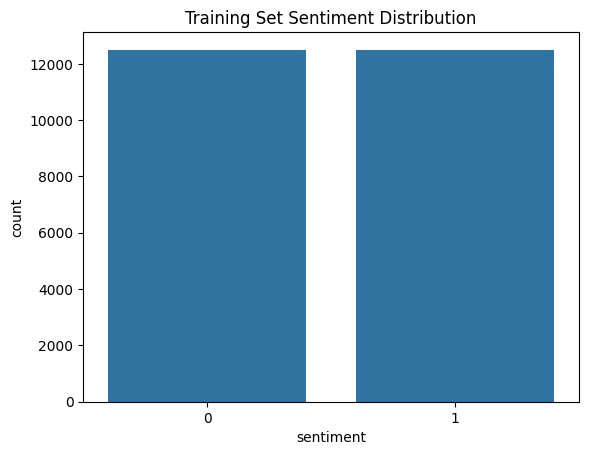

In [22]:
# Cell 8: Check class distribution
print(df_train["sentiment"].value_counts())
print(df_test["sentiment"].value_counts())

sns.countplot(x=df_train["sentiment"])
plt.title("Training Set Sentiment Distribution")
plt.show()

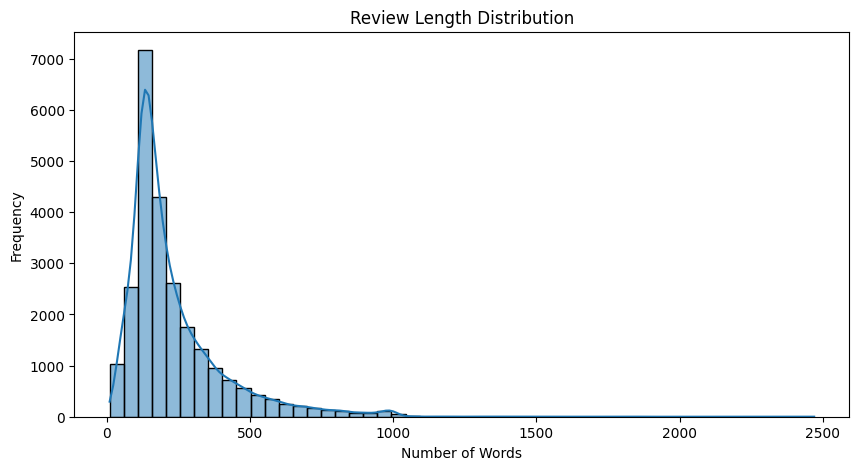

count    25000.000000
mean       233.787200
std        173.733032
min         10.000000
25%        127.000000
50%        174.000000
75%        284.000000
max       2470.000000
Name: review_length, dtype: float64

In [23]:
# Cell 9: Analyze review length distribution
df_train["review_length"] = df_train["review"].apply(lambda x: len(x.split()))

plt.figure(figsize=(10, 5))
sns.histplot(df_train["review_length"], bins=50, kde=True)
plt.title("Review Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

df_train["review_length"].describe()

In [24]:
# Cell 10: Load English stopwords
stop_words = set(stopwords.words("english"))

In [25]:
# Cell 11: Define text cleaning function
def clean_text(text, remove_stopwords=False):
    text = text.lower()
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"http\S+|www\S+|https\S+", " ", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    
    if remove_stopwords:
        words = text.split()
        words = [word for word in words if word not in stop_words]
        text = " ".join(words)
    
    return text

In [26]:
# Cell 12: Apply text cleaning to train and test sets
df_train["clean_review"] = df_train["review"].apply(lambda x: clean_text(x, remove_stopwords=False))
df_test["clean_review"] = df_test["review"].apply(lambda x: clean_text(x, remove_stopwords=False))

df_train[["review", "clean_review"]].head()

,review,clean_review
0,I watched this movie when I was almost quite a...,i watched this movie when i was almost quite a...
1,"Admittedly, I know nothing about baseball, I'm...",admittedly i know nothing about baseball i m n...
2,"In a near future, the ordinary man above any s...",in a near future the ordinary man above any su...
3,There are four great movie depicting the Vietn...,there are four great movie depicting the vietn...
4,According to the book The Last of the Cowboy H...,according to the book the last of the cowboy h...


In [27]:
# Cell 13: Split training data into train and validation sets
X_train_text, X_val_text, y_train, y_val = train_test_split(
    df_train["clean_review"],
    df_train["sentiment"],
    test_size=0.15,
    random_state=SEED,
    stratify=df_train["sentiment"]
)

X_test_text = df_test["clean_review"]
y_test = df_test["sentiment"]

print("Train samples:", len(X_train_text))
print("Validation samples:", len(X_val_text))
print("Test samples:", len(X_test_text))

Train samples: 21250
Validation samples: 3750
Test samples: 25000


In [28]:
# Cell 14: Create tokenizer with limited vocabulary
VOCAB_SIZE = 10000
MAX_LEN = 250
OOV_TOKEN = "<OOV>"

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOKEN)
tokenizer.fit_on_texts(X_train_text)

word_index = tokenizer.word_index
print("Total unique tokens found:", len(word_index))

Total unique tokens found: 68729


In [29]:
# Cell 15: Convert text into sequences
X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_val_seq = tokenizer.texts_to_sequences(X_val_text)
X_test_seq = tokenizer.texts_to_sequences(X_test_text)

In [30]:
# Cell 16: Pad all sequences to equal length
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding="post", truncating="post")
X_val_pad = pad_sequences(X_val_seq, maxlen=MAX_LEN, padding="post", truncating="post")
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding="post", truncating="post")

print("X_train_pad shape:", X_train_pad.shape)
print("X_val_pad shape:", X_val_pad.shape)
print("X_test_pad shape:", X_test_pad.shape)

X_train_pad shape: (21250, 250)
X_val_pad shape: (3750, 250)
X_test_pad shape: (25000, 250)


In [31]:
# Cell 17: Inspect one original review and its sequence
print("Original review:")
print(X_train_text.iloc[0][:500])

print("\nTokenized sequence:")
print(X_train_seq[0][:50])

print("\nPadded sequence length:")
print(len(X_train_pad[0]))

Original review:
anyone who has studied any physics or cognitive science will walk out disgusted after min as my wife and i did the ignorant masses might be entertained by the hand waiving arguments and the absurd conclusions drawn without even an attempt at a logical reason from real science i m offended by such nonsense presented under the guise of science i can only conclude that the writers picked up a quantum physics book didn t understand a word of it then watched the matrix about a thousand times and proc

Tokenized sequence:
[251, 36, 46, 7233, 100, 5591, 42, 1, 1063, 81, 1091, 45, 5728, 99, 4505, 15, 60, 306, 3, 10, 121, 2, 4271, 4792, 233, 29, 2129, 34, 2, 507, 1, 6814, 3, 2, 1727, 7610, 1268, 207, 59, 35, 573, 32, 4, 3669, 280, 38, 146, 1063, 10, 141]

Padded sequence length:
250


In [32]:
# Cell 18: Define model evaluation function
def evaluate_model(model, X_data, y_true, model_name="Model"):
    y_pred_prob = model.predict(X_data, verbose=0)
    y_pred = (y_pred_prob > 0.5).astype("int32").flatten()
    
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    
    print(f"\n{model_name} Performance")
    print("Accuracy :", round(acc, 4))
    print("Precision:", round(prec, 4))
    print("Recall   :", round(rec, 4))
    print("F1-Score :", round(f1, 4))
    
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))
    
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()
    
    return {
        "Model": model_name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1
    }

In [33]:
# Cell 19: Define training callbacks
def get_callbacks(model_name):
    callbacks = [
        EarlyStopping(
            monitor="val_loss",
            patience=3,
            restore_best_weights=True
        ),
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=2,
            verbose=1
        ),
        ModelCheckpoint(
            filepath=f"{model_name}_best.keras",
            monitor="val_loss",
            save_best_only=True,
            verbose=1
        )
    ]
    return callbacks

In [34]:
# Cell 20: Build 1D CNN model
def build_cnn_model(vocab_size, max_len):
    model = Sequential([
        Embedding(input_dim=vocab_size, output_dim=128, input_length=max_len),
        Conv1D(filters=128, kernel_size=5, activation="relu"),
        MaxPooling1D(pool_size=2),
        Conv1D(filters=64, kernel_size=3, activation="relu"),
        GlobalMaxPooling1D(),
        Dense(64, activation="relu"),
        Dropout(0.5),
        Dense(1, activation="sigmoid")
    ])
    
    model.compile(
        loss="binary_crossentropy",
        optimizer="adam",
        metrics=["accuracy"]
    )
    return model

cnn_model = build_cnn_model(VOCAB_SIZE, MAX_LEN)
cnn_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 250, 128)          1280000   
                                                                 
 conv1d (Conv1D)             (None, 246, 128)          82048     
                                                                 
 max_pooling1d (MaxPooling1  (None, 123, 128)          0         
 D)                                                              
                                                                 
 conv1d_1 (Conv1D)           (None, 121, 64)           24640     
                                                                 
 global_max_pooling1d (Glob  (None, 64)                0         
 alMaxPooling1D)                                                 
                                                                 
 dense (Dense)               (None, 64)                4

2026-05-09 19:45:18.405143: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-05-09 19:45:18.421705: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2256] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [35]:
# Cell 21: Train 1D CNN model
history_cnn = cnn_model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=10,
    batch_size=64,
    callbacks=get_callbacks("cnn_model"),
    verbose=1
)

Epoch 1/10
332/333 [============================>.] - ETA: 0s - loss: 0.5006 - accuracy: 0.7385
Epoch 1: val_loss improved from inf to 0.35601, saving model to cnn_model_best.keras
333/333 [==============================] - 23s 68ms/step - loss: 0.5006 - accuracy: 0.7384 - val_loss: 0.3560 - val_accuracy: 0.8445 - lr: 0.0010
Epoch 2/10
332/333 [============================>.] - ETA: 0s - loss: 0.2668 - accuracy: 0.8956
Epoch 2: val_loss improved from 0.35601 to 0.34010, saving model to cnn_model_best.keras
333/333 [==============================] - 45s 135ms/step - loss: 0.2668 - accuracy: 0.8956 - val_loss: 0.3401 - val_accuracy: 0.8464 - lr: 0.0010
Epoch 3/10
332/333 [============================>.] - ETA: 0s - loss: 0.1366 - accuracy: 0.9548
Epoch 3: val_loss did not improve from 0.34010
333/333 [==============================] - 58s 174ms/step - loss: 0.1366 - accuracy: 0.9548 - val_loss: 0.4228 - val_accuracy: 0.8429 - lr: 0.0010
Epoch 4/10
332/333 [============================>.]


1D CNN Performance
Accuracy : 0.8512
Precision: 0.8333
Recall   : 0.8782
F1-Score : 0.8551

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.82      0.85     12500
           1       0.83      0.88      0.86     12500

    accuracy                           0.85     25000
   macro avg       0.85      0.85      0.85     25000
weighted avg       0.85      0.85      0.85     25000



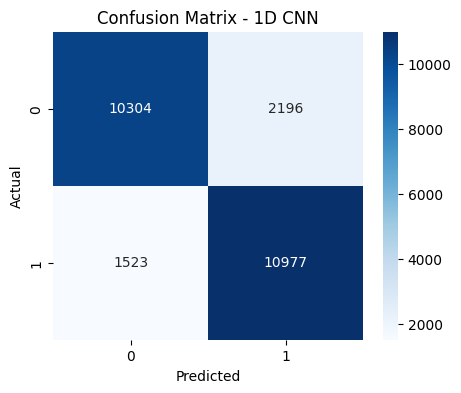

In [36]:
# Cell 22: Evaluate 1D CNN model
cnn_results = evaluate_model(cnn_model, X_test_pad, y_test, model_name="1D CNN")

In [37]:
# Cell 23: Build Bidirectional LSTM model
def build_bilstm_model(vocab_size, max_len):
    model = Sequential([
        Embedding(input_dim=vocab_size, output_dim=128, input_length=max_len),
        Bidirectional(LSTM(128, dropout=0.3, recurrent_dropout=0.3)),
        Dense(64, activation="relu"),
        Dropout(0.5),
        Dense(1, activation="sigmoid")
    ])
    
    model.compile(
        loss="binary_crossentropy",
        optimizer="adam",
        metrics=["accuracy"]
    )
    return model

bilstm_model = build_bilstm_model(VOCAB_SIZE, MAX_LEN)
bilstm_model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_1 (Embedding)     (None, 250, 128)          1280000   
                                                                 
 bidirectional (Bidirection  (None, 256)               263168    
 al)                                                             
                                                                 
 dense_2 (Dense)             (None, 64)                16448     
                                                                 
 dropout_1 (Dropout)         (None, 64)                0         
                                                                 
 dense_3 (Dense)             (None, 1)                 65        
                                                                 
Total params: 1559681 (5.95 MB)
Trainable params: 1559681 (5.95 MB)
Non-trainable params: 0 (0.00 Byte)
________________

In [38]:
# Cell 24: Train Bidirectional LSTM model
history_bilstm = bilstm_model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=10,
    batch_size=64,
    callbacks=get_callbacks("bilstm_model"),
    verbose=1
)

Epoch 1/10
333/333 [==============================] - ETA: 0s - loss: 0.5475 - accuracy: 0.7007
Epoch 1: val_loss improved from inf to 0.36964, saving model to bilstm_model_best.keras
333/333 [==============================] - 357s 1s/step - loss: 0.5475 - accuracy: 0.7007 - val_loss: 0.3696 - val_accuracy: 0.8477 - lr: 0.0010
Epoch 2/10
333/333 [==============================] - ETA: 0s - loss: 0.3394 - accuracy: 0.8624
Epoch 2: val_loss improved from 0.36964 to 0.35463, saving model to bilstm_model_best.keras
333/333 [==============================] - 371s 1s/step - loss: 0.3394 - accuracy: 0.8624 - val_loss: 0.3546 - val_accuracy: 0.8525 - lr: 0.0010
Epoch 3/10
333/333 [==============================] - ETA: 0s - loss: 0.2434 - accuracy: 0.9110
Epoch 3: val_loss improved from 0.35463 to 0.35174, saving model to bilstm_model_best.keras
333/333 [==============================] - 245s 736ms/step - loss: 0.2434 - accuracy: 0.9110 - val_loss: 0.3517 - val_accuracy: 0.8640 - lr: 0.0010
Ep


BiLSTM Performance
Accuracy : 0.8519
Precision: 0.8575
Recall   : 0.8441
F1-Score : 0.8507

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.86      0.85     12500
           1       0.86      0.84      0.85     12500

    accuracy                           0.85     25000
   macro avg       0.85      0.85      0.85     25000
weighted avg       0.85      0.85      0.85     25000



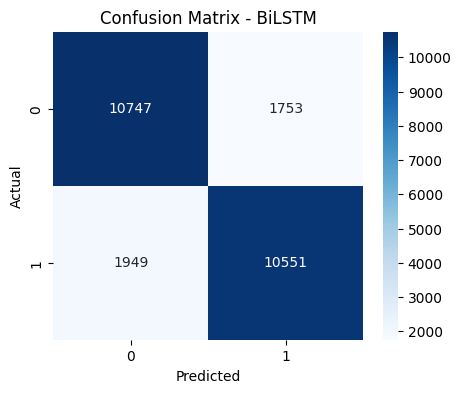

In [39]:
# Cell 25: Evaluate Bidirectional LSTM model
bilstm_results = evaluate_model(bilstm_model, X_test_pad, y_test, model_name="BiLSTM")

In [40]:
# Cell 26: Build GRU model
def build_gru_model(vocab_size, max_len):
    model = Sequential([
        Embedding(input_dim=vocab_size, output_dim=128, input_length=max_len),
        GRU(128, dropout=0.3, recurrent_dropout=0.3),
        Dense(64, activation="relu"),
        Dropout(0.5),
        Dense(1, activation="sigmoid")
    ])
    
    model.compile(
        loss="binary_crossentropy",
        optimizer="adam",
        metrics=["accuracy"]
    )
    return model

gru_model = build_gru_model(VOCAB_SIZE, MAX_LEN)
gru_model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_2 (Embedding)     (None, 250, 128)          1280000   
                                                                 
 gru (GRU)                   (None, 128)               99072     
                                                                 
 dense_4 (Dense)             (None, 64)                8256      
                                                                 
 dropout_2 (Dropout)         (None, 64)                0         
                                                                 
 dense_5 (Dense)             (None, 1)                 65        
                                                                 
Total params: 1387393 (5.29 MB)
Trainable params: 1387393 (5.29 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [41]:
# Cell 27: Train GRU model
history_gru = gru_model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=10,
    batch_size=64,
    callbacks=get_callbacks("gru_model"),
    verbose=1
)

Epoch 1/10
333/333 [==============================] - ETA: 0s - loss: 0.6934 - accuracy: 0.5067
Epoch 1: val_loss improved from inf to 0.69319, saving model to gru_model_best.keras
333/333 [==============================] - 83s 244ms/step - loss: 0.6934 - accuracy: 0.5067 - val_loss: 0.6932 - val_accuracy: 0.5051 - lr: 0.0010
Epoch 2/10
333/333 [==============================] - ETA: 0s - loss: 0.7002 - accuracy: 0.5290
Epoch 2: val_loss improved from 0.69319 to 0.69122, saving model to gru_model_best.keras
333/333 [==============================] - 81s 242ms/step - loss: 0.7002 - accuracy: 0.5290 - val_loss: 0.6912 - val_accuracy: 0.5107 - lr: 0.0010
Epoch 3/10
333/333 [==============================] - ETA: 0s - loss: 0.6090 - accuracy: 0.6421
Epoch 3: val_loss improved from 0.69122 to 0.37395, saving model to gru_model_best.keras
333/333 [==============================] - 80s 240ms/step - loss: 0.6090 - accuracy: 0.6421 - val_loss: 0.3740 - val_accuracy: 0.8445 - lr: 0.0010
Epoch 4/


GRU Performance
Accuracy : 0.8646
Precision: 0.8894
Recall   : 0.8329
F1-Score : 0.8602

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.90      0.87     12500
           1       0.89      0.83      0.86     12500

    accuracy                           0.86     25000
   macro avg       0.87      0.86      0.86     25000
weighted avg       0.87      0.86      0.86     25000



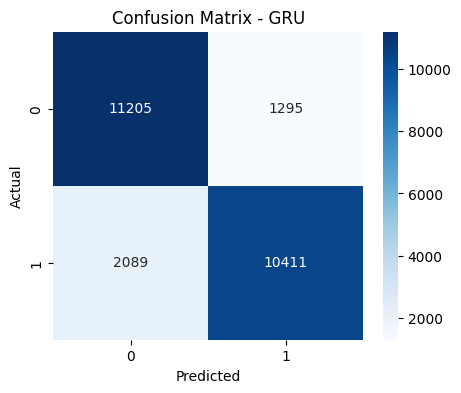

In [42]:
# Cell 28: Evaluate GRU model
gru_results = evaluate_model(gru_model, X_test_pad, y_test, model_name="GRU")

In [43]:
# Cell 29: Combine model results in one table
results_df = pd.DataFrame([cnn_results, bilstm_results, gru_results])
results_df = results_df.sort_values(by="F1", ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision,Recall,F1
0,GRU,0.86464,0.889373,0.83288,0.86020
1,1D CNN,0.85124,0.833295,0.87816,0.85514
2,BiLSTM,0.85192,0.857526,0.84408,0.85075


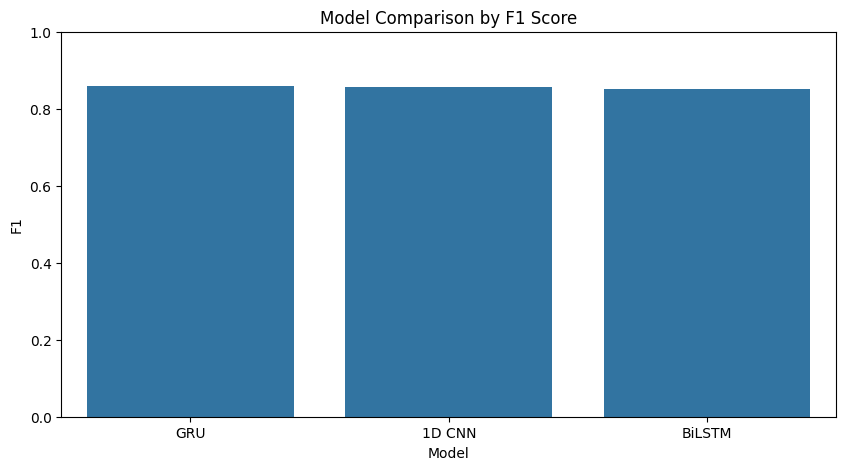

In [44]:
# Cell 30: Plot F1-score comparison for all models
plt.figure(figsize=(10, 5))
sns.barplot(x="Model", y="F1", data=results_df)
plt.title("Model Comparison by F1 Score")
plt.ylim(0, 1)
plt.show()

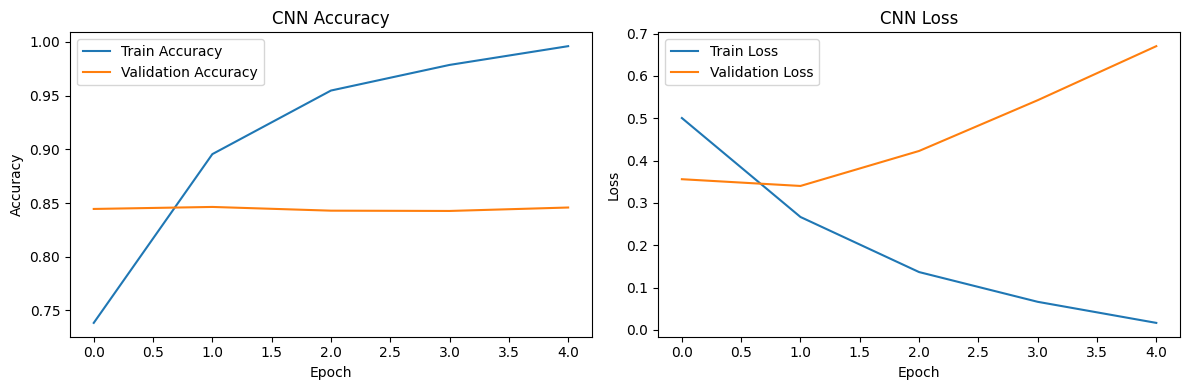

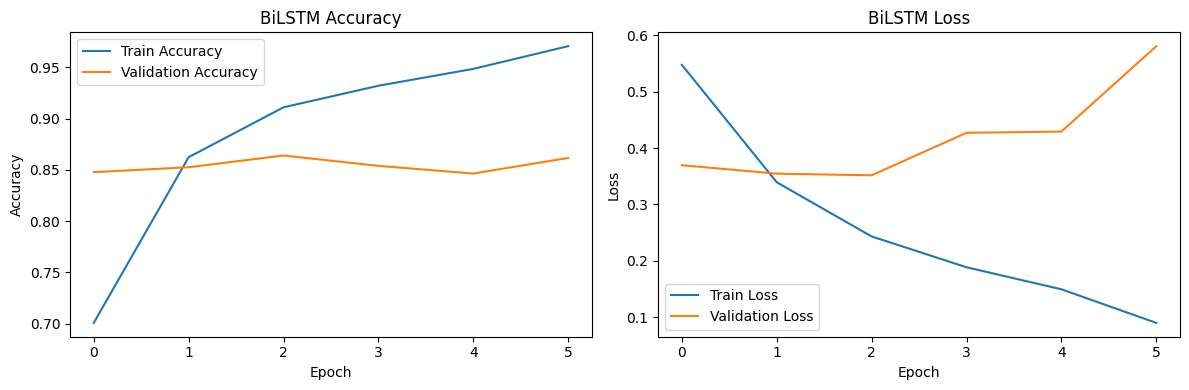

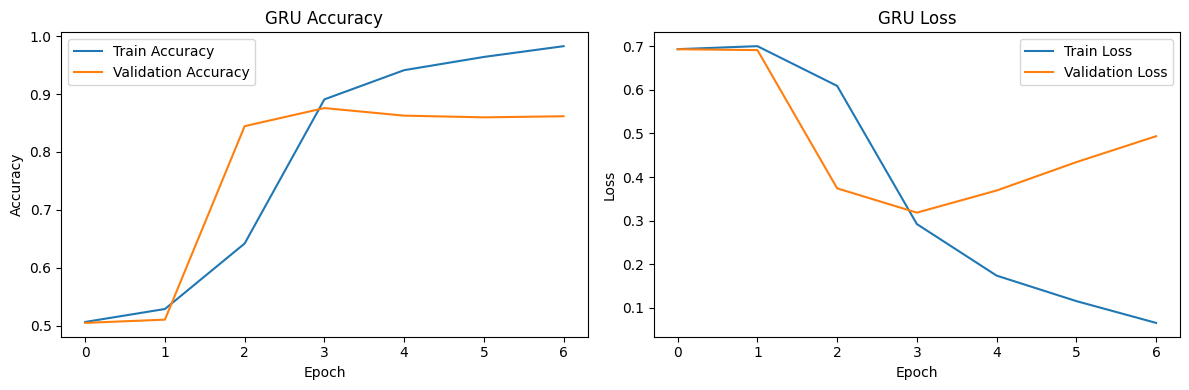

In [45]:
# Cell 31: Define function to plot training history
def plot_history(history, title):
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.plot(history.history["accuracy"], label="Train Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
    plt.title(f"{title} Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.title(f"{title} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    
    plt.tight_layout()
    plt.show()

plot_history(history_cnn, "CNN")
plot_history(history_bilstm, "BiLSTM")
plot_history(history_gru, "GRU")

In [46]:
# Cell 32: Define function for custom sentiment prediction
def predict_sentiment(text, model, tokenizer, max_len):
    cleaned_text = clean_text(text)
    sequence = tokenizer.texts_to_sequences([cleaned_text])
    padded_sequence = pad_sequences(sequence, maxlen=max_len, padding="post", truncating="post")
    
    prediction_prob = model.predict(padded_sequence, verbose=0)[0][0]
    prediction_label = 1 if prediction_prob > 0.5 else 0
    sentiment = "Positive" if prediction_label == 1 else "Negative"
    
    print("Review:", text)
    print("Predicted Sentiment:", sentiment)
    print("Confidence:", round(float(prediction_prob), 4))

In [47]:
# Cell 33: Test predictions on sample reviews
sample_review_1 = "This movie was fantastic, emotional, and brilliantly acted."
sample_review_2 = "It was boring, too long, and a complete waste of time."

predict_sentiment(sample_review_1, bilstm_model, tokenizer, MAX_LEN)
predict_sentiment(sample_review_2, bilstm_model, tokenizer, MAX_LEN)

Review: This movie was fantastic, emotional, and brilliantly acted.
Predicted Sentiment: Positive
Confidence: 0.9551
Review: It was boring, too long, and a complete waste of time.
Predicted Sentiment: Negative
Confidence: 0.0073


In [48]:
# Cell 34: Save tokenizer and results
import pickle

with open("tokenizer.pkl", "wb") as file:
    pickle.dump(tokenizer, file)

results_df.to_csv("model_comparison_results.csv", index=False)

print("Tokenizer and results saved successfully.")

Tokenizer and results saved successfully.


In [49]:
# Cell 35: Show the best performing model
best_model_name = results_df.iloc[0]["Model"]
print("Best performing model:", best_model_name)
print(results_df)

Best performing model: GRU
    Model  Accuracy  Precision   Recall       F1
0     GRU   0.86464   0.889373  0.83288  0.86020
1  1D CNN   0.85124   0.833295  0.87816  0.85514
2  BiLSTM   0.85192   0.857526  0.84408  0.85075
